In [1]:
%pip install pandas 
%pip install matplotlib
%pip install numpy
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns

In [3]:
df = pd.read_csv("heart.csv");
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
913    False
914    False
915    False
916    False
917    False
Length: 918, dtype: bool

In [5]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


<Axes: xlabel='HeartDisease'>

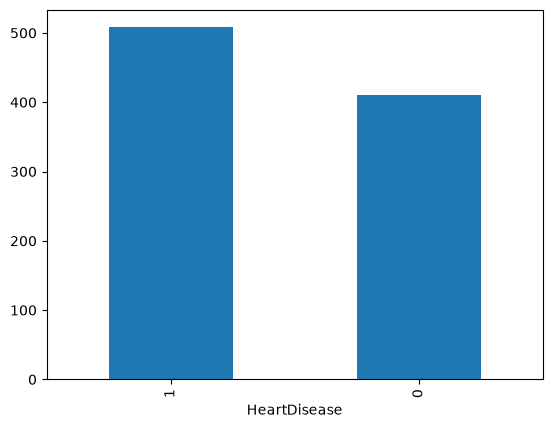

In [8]:
df["HeartDisease"].value_counts().plot(kind="bar")

In [9]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


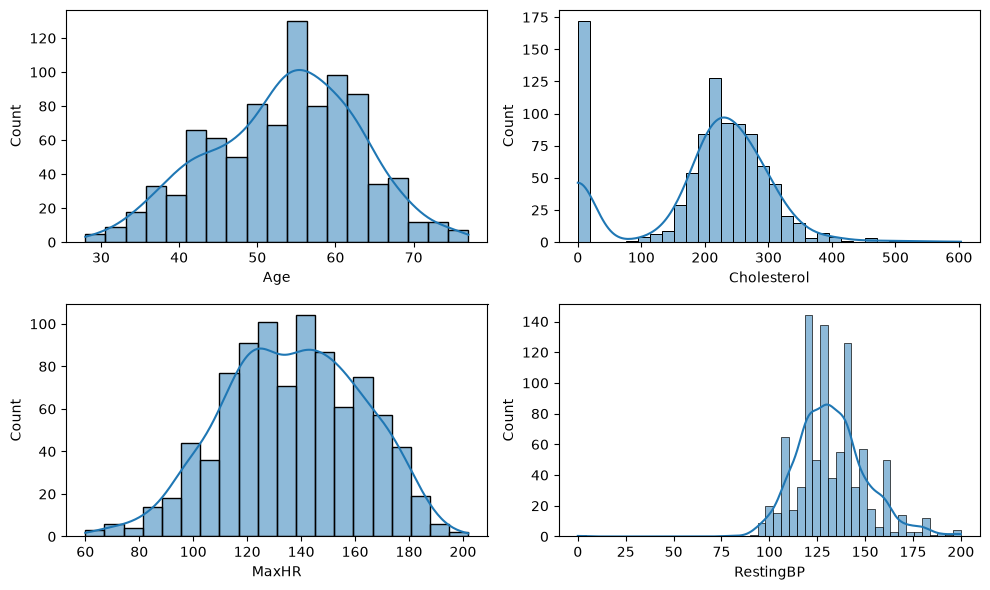

In [10]:
def plotting (var , num):
    plt.subplot(2,2,num); # it creates 4 plots-canvas
    sns.histplot(df[var] , kde=True) # it is render inside that 4 plots

plt.figure(figsize=(10,6))

plotting("Age",1)
plotting("Cholesterol",2)
plotting("MaxHR",3)
plotting("RestingBP",4)

plt.tight_layout()
plt.show()
    

here in plots you can see there are multiple peope how have 0 number of RestingBP which is impossible , and i colestrol there is also a lot of people with 0 colestrol level which is again impossible in human body so for this we will take the mean of the data and put there inside of Zeros.

In [11]:
df['RestingBP'].value_counts()
df["Cholesterol"].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [12]:
cholestrol_mean = df.loc[df["Cholesterol"] != 0 , "Cholesterol"].mean()

In [13]:
df['Cholesterol'] = df['Cholesterol'].replace(0 , cholestrol_mean)

In [14]:
df['Cholesterol'].round(2)

0      289.0
1      180.0
2      283.0
3      214.0
4      195.0
       ...  
913    264.0
914    193.0
915    131.0
916    236.0
917    175.0
Name: Cholesterol, Length: 918, dtype: float64

<Axes: xlabel='Cholesterol', ylabel='Count'>

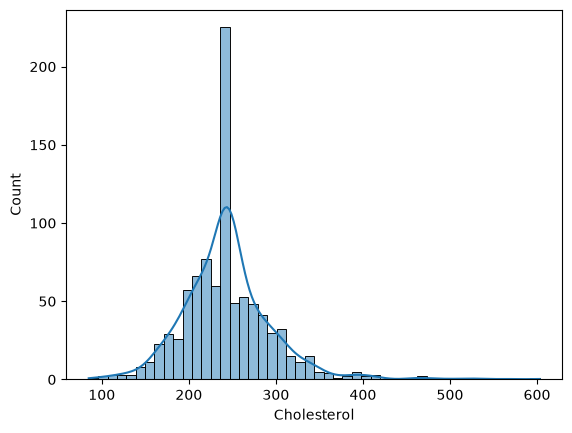

In [15]:
sns.histplot(df['Cholesterol'] , kde=True)

In [16]:
RestingBP_mean = df.loc[df['RestingBP'] != 0 , "RestingBP"].mean()
df['RestingBP'] = df['RestingBP'].replace(0 , RestingBP_mean).round(2)
df['RestingBP'].value_counts()

RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
174.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 67, dtype: int64

<Axes: xlabel='RestingBP', ylabel='Count'>

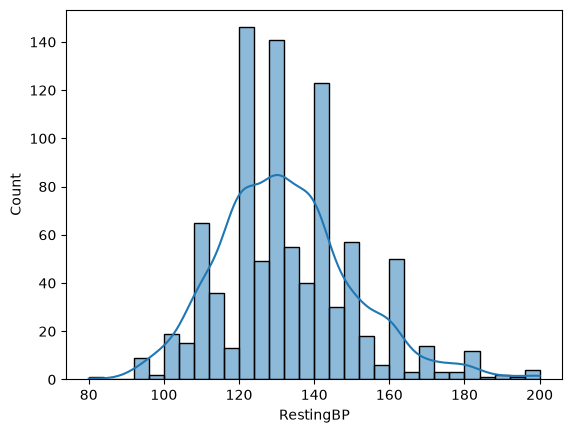

In [17]:
sns.histplot(df['RestingBP'] , kde=True )

In [18]:
%pip install sheryanalysis

Note: you may need to restart the kernel to use updated packages.


In [19]:
import sheryanalysis as sh 

In [20]:
sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 12)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


c:\Users\zulka\anaconda3\envs\ml-learning\Lib\site-packages\sheryanalysis\utils.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(sample)
c:\Users\zulka\anaconda3\envs\ml-learning\Lib\site-packages\sheryanalysis\utils.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(sample)
c:\Users\zulka\anaconda3\envs\ml-learning\Lib\site-packages\sheryanalysis\utils.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(sample)
c:\Users\zulka\anaconda3\envs\ml-learning\Lib\site-packages\sheryanalysis\utils.py:103: UserWarning: Could no

{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': <StringDtype(storage='python', na_value=nan)>,
  'ChestPainType': <StringDtype(storage='python', na_value=nan)>,
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': <StringDtype(storage='python', na_value=nan)>,
  'MaxHR': dtype('int64'),
  'ExerciseAngina': <StringDtype(storage='python', na_value=nan)>,
  'Oldpeak': dtype('float64'),
  'ST_Slope': <StringDtype(storage='python', na_value=nan)>,
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'c

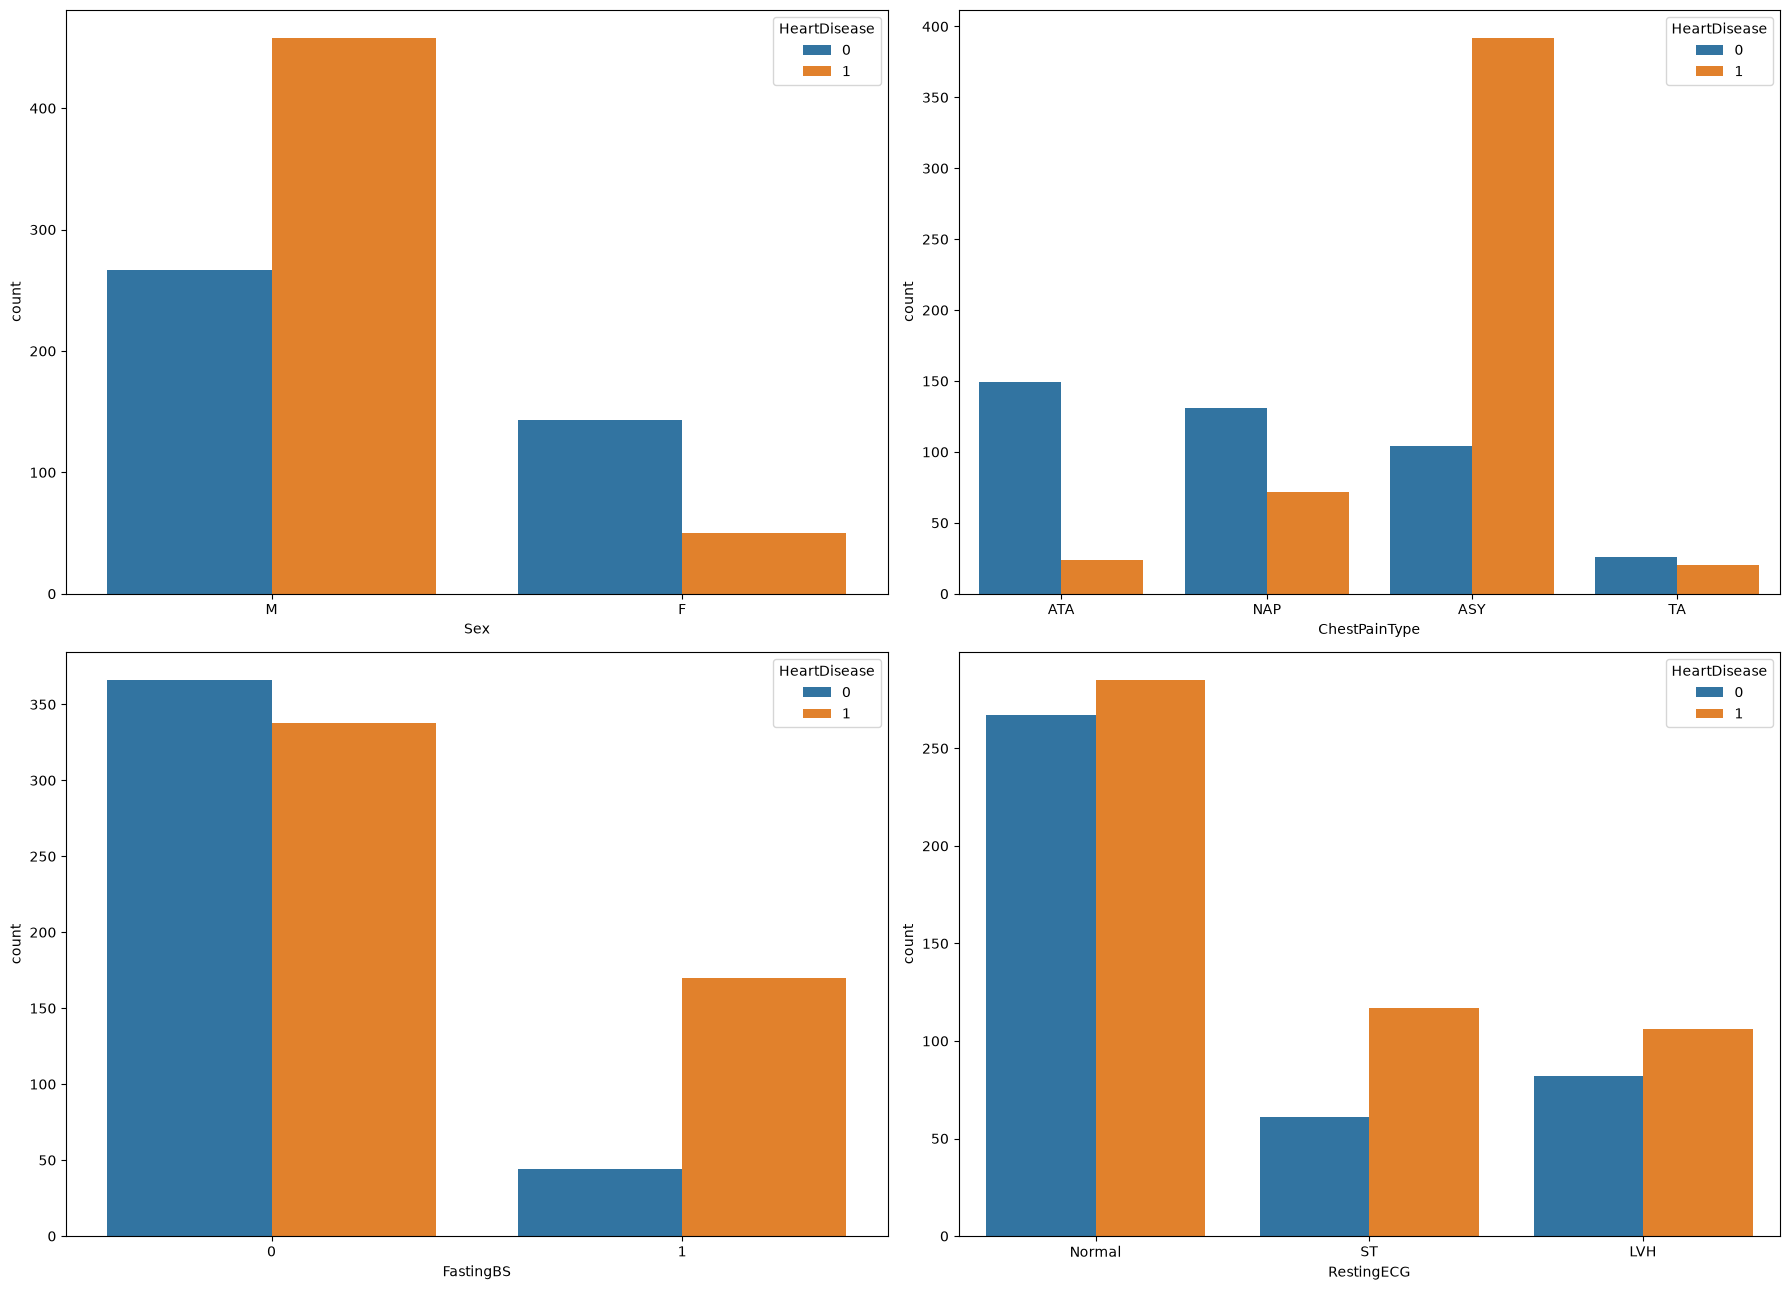

In [21]:
def plotting_catgorial (var , num):
    plt.subplot(2,2,num); # it creates 4 plots-canvas
    sns.countplot(x=df[var] , hue=df['HeartDisease']) # it is render inside that 4 plots
    
    # due to hue=df['HeartDisease'] we can predict that which value is more affecting heart disease
    # like in plotting we can see men who have ASY pain they have a high risk of  getting heart disease

# plotting for catagorial features/columns
plt.figure(figsize=(18,13))
plotting_catgorial("Sex",1)
plotting_catgorial("ChestPainType",2)
plotting_catgorial("FastingBS",3)
plotting_catgorial("RestingECG",4)

plt.tight_layout()
plt.show()

<Axes: xlabel='HeartDisease', ylabel='Age'>

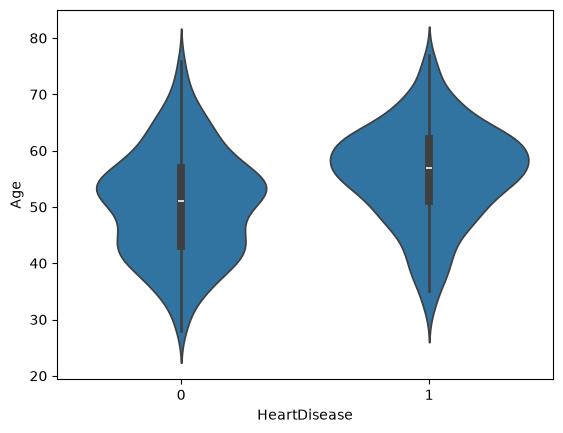

In [22]:
sns.violinplot(x=df['HeartDisease'], y=df['Age']  , data=df)
# here you can see that in age of 50-60 and 60-70 getting heart desease is like normal 

<Axes: >

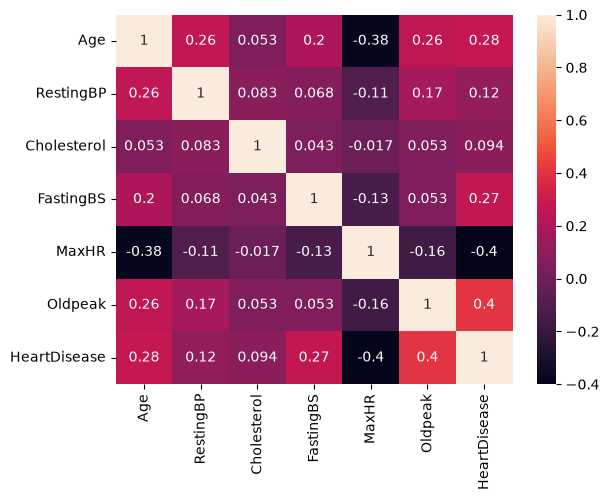

In [23]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
# here age have a more affect on heart disease and then BP , and oldpeak they are very close with heart disease

In [24]:
# Data PreProcessing 


df_encoding = pd.get_dummies(df , drop_first=True)

In [25]:
df_encoding

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [26]:
df_encoding = df_encoding.astype(int)

In [27]:
%pip install scikit-learn
from sklearn.preprocessing import StandardScaler

col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

scaler = StandardScaler()

df_encoding[col] = scaler.fit_transform(df_encoding[col])
df_encoding.head()

Note: you may need to restart the kernel to use updated packages.


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [ ]:
# Feature Engneering , scaling and Selection in progress 